# Classical ML Training & Evaluation

Trains RF, SVR, GPR, and naive baseline through cell-based LOOCV on
the NASA PCoE dataset. Reports RMSE, MAE, MaxAE, R² per fold and
aggregated across folds.

In [5]:
import sys
sys.path.insert(0, "..")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.evaluation.validation import cell_based_loocv, scale_features
from src.evaluation.metrics import compute_all_metrics
from src.models.baseline import NaiveBaseline
from src.models.rf_model import train_rf
from src.models.svr_model import train_svr
from src.models.gpr_model import train_gpr

logging.basicConfig(level=logging.INFO)
sns.set_theme(style="whitegrid", context="notebook")

with open("../config/default.yaml") as f:
    config = yaml.safe_load(f)

feature_df = pd.read_parquet("../data/features/feature_matrix.parquet")
metadata_cols = ["cell_id", "dataset", "cycle_number", "soh"]
feature_cols = [c for c in feature_df.columns if c not in metadata_cols]

print(f"Feature matrix: {feature_df.shape}")
print(f"Features: {feature_cols}")
print(f"Cells: {feature_df['cell_id'].unique().tolist()}")

Feature matrix: (636, 16)
Features: ['mean_discharge_voltage', 'internal_resistance', 'discharge_energy', 'eis_re', 'capacity_fade_rate', 'temp_mean', 'temp_max', 'temp_range', 'ica_peak_voltage', 'temp_min', 'ica_peak_height', 'ica_peak_area']
Cells: ['B0005', 'B0006', 'B0007', 'B0018']


## 1. Create LOOCV Folds

In [6]:
folds = cell_based_loocv(feature_df, feature_cols)
for f in folds:
    print(f"Fold {f['fold']}: test={f['test_cell']}, train={len(f['X_train'])}, test={len(f['X_test'])}")

INFO:src.evaluation.validation:Fold 0: test_cell=B0005, train=437, test=160
INFO:src.evaluation.validation:Fold 1: test_cell=B0006, train=446, test=151
INFO:src.evaluation.validation:Fold 2: test_cell=B0007, train=437, test=160
INFO:src.evaluation.validation:Fold 3: test_cell=B0018, train=471, test=126
INFO:src.evaluation.validation:Created 4 LOOCV folds


Fold 0: test=B0005, train=437, test=160
Fold 1: test=B0006, train=446, test=151
Fold 2: test=B0007, train=437, test=160
Fold 3: test=B0018, train=471, test=126


## 2. Run All Models

In [7]:
import time

all_results = {"naive": [], "rf": [], "svr": [], "gpr": []}

for fold in folds:
    X_train, y_train = fold["X_train"], fold["y_train"]
    X_test, y_test = fold["X_test"], fold["y_test"]
    X_train_s, X_test_s, scaler = scale_features(X_train, X_test)

    print(f"\n--- Fold {fold['fold']}: test cell {fold['test_cell']} ---")

    t0 = time.perf_counter()
    baseline = NaiveBaseline().fit(X_train_s, y_train)
    y_pred = baseline.predict(X_test_s)
    metrics = compute_all_metrics(y_test, y_pred)
    metrics["time"] = time.perf_counter() - t0
    all_results["naive"].append(metrics)
    print(f"  Naive: RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

    t0 = time.perf_counter()
    rf_cfg = config["models"]["classical"]["rf"]
    model, params, metrics = train_rf(
        X_train_s, y_train, X_test_s, y_test,
        n_trials=rf_cfg["n_trials"],
        param_space={
            "n_estimators": tuple(rf_cfg["param_space"]["n_estimators"]),
            "max_depth": rf_cfg["param_space"]["max_depth"],
            "min_samples_leaf": tuple(rf_cfg["param_space"]["min_samples_leaf"]),
            "max_features": rf_cfg["param_space"]["max_features"],
        },
    )
    metrics["time"] = time.perf_counter() - t0
    all_results["rf"].append(metrics)
    print(f"  RF:    RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

    t0 = time.perf_counter()
    svr_cfg = config["models"]["classical"]["svr"]
    model, params, metrics = train_svr(
        X_train_s, y_train, X_test_s, y_test,
        n_trials=svr_cfg["n_trials"],
        param_space={
            "C": tuple(svr_cfg["param_space"]["C"]),
            "epsilon": tuple(svr_cfg["param_space"]["epsilon"]),
            "gamma": svr_cfg["param_space"]["gamma"],
        },
    )
    metrics["time"] = time.perf_counter() - t0
    all_results["svr"].append(metrics)
    print(f"  SVR:   RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

    t0 = time.perf_counter()
    gpr_cfg = config["models"]["classical"]["gpr"]
    model, metrics = train_gpr(
        X_train_s, y_train, X_test_s, y_test,
        max_train_samples=gpr_cfg["max_train_samples"],
        n_restarts=gpr_cfg["n_restarts_optimizer"],
    )
    metrics["time"] = time.perf_counter() - t0
    all_results["gpr"].append(metrics)
    print(f"  GPR:   RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

[I 2026-08-02 13:47:41,598] A new study created in memory with name: no-name-0fe914bb-2f4c-497d-b22a-d0de35ed16f3



--- Fold 0: test cell B0005 ---
  Naive: RMSE=0.107638 R2=-0.0786


[I 2026-08-02 13:47:41,801] Trial 0 finished with value: 0.01564587274371421 and parameters: {'n_estimators': 250, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 0.5}. Best is trial 0 with value: 0.01564587274371421.
[I 2026-08-02 13:47:41,988] Trial 1 finished with value: 0.017946880738000576 and parameters: {'n_estimators': 341, 'max_depth': None, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.01564587274371421.
[I 2026-08-02 13:47:42,112] Trial 2 finished with value: 0.01623814315419229 and parameters: {'n_estimators': 222, 'max_depth': 10, 'min_samples_leaf': 7, 'max_features': 0.5}. Best is trial 0 with value: 0.01564587274371421.
[I 2026-08-02 13:47:42,274] Trial 3 finished with value: 0.01780561489926527 and parameters: {'n_estimators': 282, 'max_depth': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.01564587274371421.
[I 2026-08-02 13:47:42,356] Trial 4 finished with value: 0.018325500447635878 and param

  RF:    RMSE=0.014329 R2=0.9809


[I 2026-08-02 13:47:58,132] Trial 25 finished with value: 0.011777979859409827 and parameters: {'C': 0.032327553691375785, 'epsilon': 0.002206213263577026, 'gamma': 'scale'}. Best is trial 25 with value: 0.011777979859409827.
[I 2026-08-02 13:47:58,142] Trial 26 finished with value: 0.0911351514435025 and parameters: {'C': 0.027825592410310594, 'epsilon': 0.020811047729416297, 'gamma': 1.0}. Best is trial 25 with value: 0.011777979859409827.
[I 2026-08-02 13:47:58,190] Trial 27 finished with value: 0.01686030496897021 and parameters: {'C': 10.853781233608892, 'epsilon': 0.001570544261386534, 'gamma': 'auto'}. Best is trial 25 with value: 0.011777979859409827.
[I 2026-08-02 13:47:58,198] Trial 28 finished with value: 0.02040324777653757 and parameters: {'C': 0.010207673678163255, 'epsilon': 0.01842520621836722, 'gamma': 'scale'}. Best is trial 25 with value: 0.011777979859409827.
[I 2026-08-02 13:47:58,205] Trial 29 finished with value: 0.022616853280479517 and parameters: {'C': 0.61290

...

  RF:    RMSE=0.020193 R2=0.9410


[I 2026-08-02 13:48:56,239] Trial 25 finished with value: 0.050975933836984885 and parameters: {'C': 391.71590647777145, 'epsilon': 0.049028322737144955, 'gamma': 0.0001}. Best is trial 20 with value: 0.02076966671983723.
[I 2026-08-02 13:48:56,246] Trial 26 finished with value: 0.03462098926107313 and parameters: {'C': 95.52619252354758, 'epsilon': 0.03913936706606609, 'gamma': 0.0001}. Best is trial 20 with value: 0.02076966671983723.
[I 2026-08-02 13:48:56,274] Trial 27 finished with value: 0.025265230610490113 and parameters: {'C': 17.153588843905563, 'epsilon': 0.029316059840089254, 'gamma': 0.0001}. Best is trial 20 with value: 0.02076966671983723.
[I 2026-08-02 13:48:56,286] Trial 28 finished with value: 0.05881640212242747 and parameters: {'C': 61.1323242183255, 'epsilon': 0.05637880095476963, 'gamma': 0.0001}. Best is trial 20 with value: 0.02076966671983723.
[I 2026-08-02 13:48:56,294] Trial 29 finished with value: 0.07933133748948246 and parameters: {'C': 5.303212542438702, 

  SVR:   RMSE=0.020122 R2=0.9414


/opt/anaconda3/envs/soh/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
INFO:src.models.gpr_model:GPR fitted. Final kernel: Matern(length_scale=14.8, nu=1.5) + WhiteKernel(noise_level=8.73e-05)
INFO:src.models.gpr_model:GPR test metrics: {'rmse': 0.037473485742495344, 'mae': 0.03559308049069119, 'maxae': 0.08128167297466726, 'r2': 0.7967977629072914}


  GPR:   RMSE=0.037473 R2=0.7968


## 3. Results Summary Table

In [8]:
rows = []
for model_name, fold_metrics in all_results.items():
    for metric in ["rmse", "mae", "maxae", "r2"]:
        vals = [m[metric] for m in fold_metrics]
        rows.append({
            "Model": model_name.upper(),
            "Metric": metric.upper(),
            "Mean": np.mean(vals),
            "Std": np.std(vals),
        })

summary_df = pd.DataFrame(rows)
pivot = summary_df.pivot(index="Model", columns="Metric", values=["Mean", "Std"])
pivot.columns = [f"{s}_{m}" for m, s in pivot.columns]
pivot = pivot[["RMSE_Mean", "RMSE_Std", "MAE_Mean", "MAE_Std", "MAXAE_Mean", "MAXAE_Std", "R2_Mean", "R2_Std"]]
pivot = pivot.sort_values("RMSE_Mean")
print(pivot.to_string(float_format="%.6f"))


       RMSE_Mean  RMSE_Std  MAE_Mean  MAE_Std  MAXAE_Mean  MAXAE_Std   R2_Mean   R2_Std
Model                                                                                  
SVR     0.015025  0.005611  0.010623 0.003781    0.054004   0.016540  0.972900 0.019861
RF      0.025052  0.016883  0.019630 0.014229    0.083925   0.035862  0.926627 0.072575
GPR     0.029786  0.018711  0.027226 0.019333    0.097737   0.019520  0.885342 0.096640
NAIVE   0.112007  0.026619  0.096459 0.024578    0.202872   0.046925 -0.285350 0.249911


## 4. Fold-wise RMSE Comparison

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


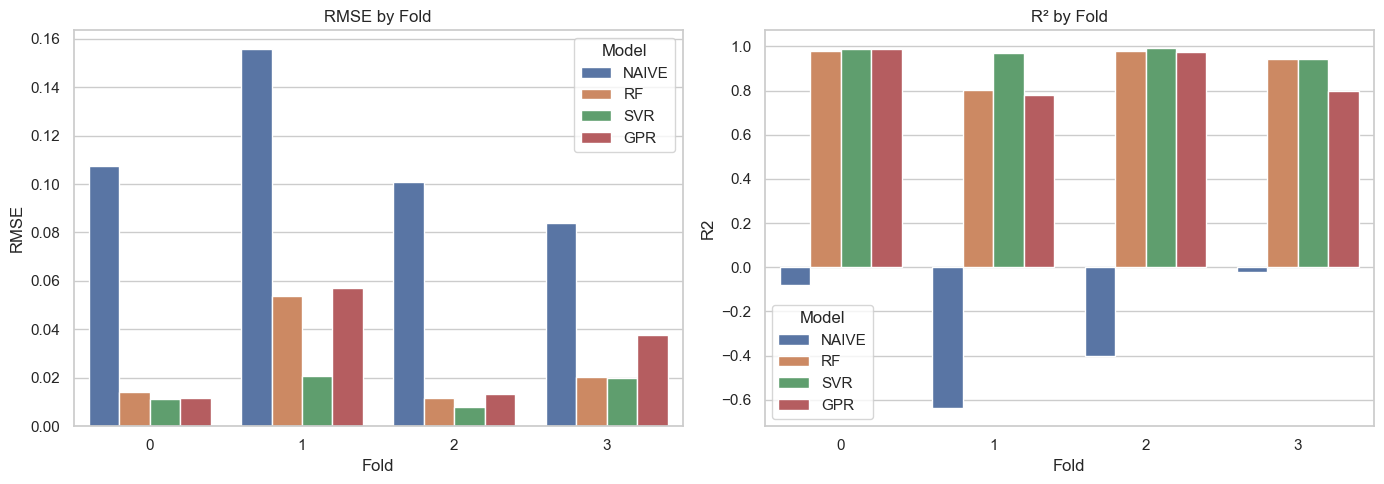

In [9]:
fold_rows = []
for model_name, fold_metrics in all_results.items():
    for i, m in enumerate(fold_metrics):
        fold_rows.append({"Model": model_name.upper(), "Fold": i, "RMSE": m["rmse"], "R2": m["r2"]})

fold_df = pd.DataFrame(fold_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=fold_df, x="Fold", y="RMSE", hue="Model", ax=axes[0])
axes[0].set_title("RMSE by Fold")

sns.barplot(data=fold_df, x="Fold", y="R2", hue="Model", ax=axes[1])
axes[1].set_title("R² by Fold")

plt.tight_layout()
plt.show()

## 5. Prediction vs. SOH Scatter (Best Model)

[I 2026-08-02 13:48:59,447] A new study created in memory with name: no-name-2b4164ef-9522-4f1b-b494-7d1660b1cd4f
[I 2026-08-02 13:48:59,450] Trial 0 finished with value: 0.056565631556380724 and parameters: {'C': 0.7459343285726545, 'epsilon': 0.0951207163345817, 'gamma': 'scale'}. Best is trial 0 with value: 0.056565631556380724.
[I 2026-08-02 13:48:59,453] Trial 1 finished with value: 0.09997891511131062 and parameters: {'C': 0.0195172246414495, 'epsilon': 0.08675143843171859, 'gamma': 1.0}. Best is trial 0 with value: 0.056565631556380724.
[I 2026-08-02 13:48:59,458] Trial 2 finished with value: 0.08854610212710172 and parameters: {'C': 145.28246637516014, 'epsilon': 0.022021571957149343, 'gamma': 1.0}. Best is trial 0 with value: 0.056565631556380724.
[I 2026-08-02 13:48:59,460] Trial 3 finished with value: 0.01921345195673861 and parameters: {'C': 1.4445251022763053, 'epsilon': 0.029831684879606152, 'gamma': 'scale'}. Best is trial 3 with value: 0.01921345195673861.
[I 2026-08-02

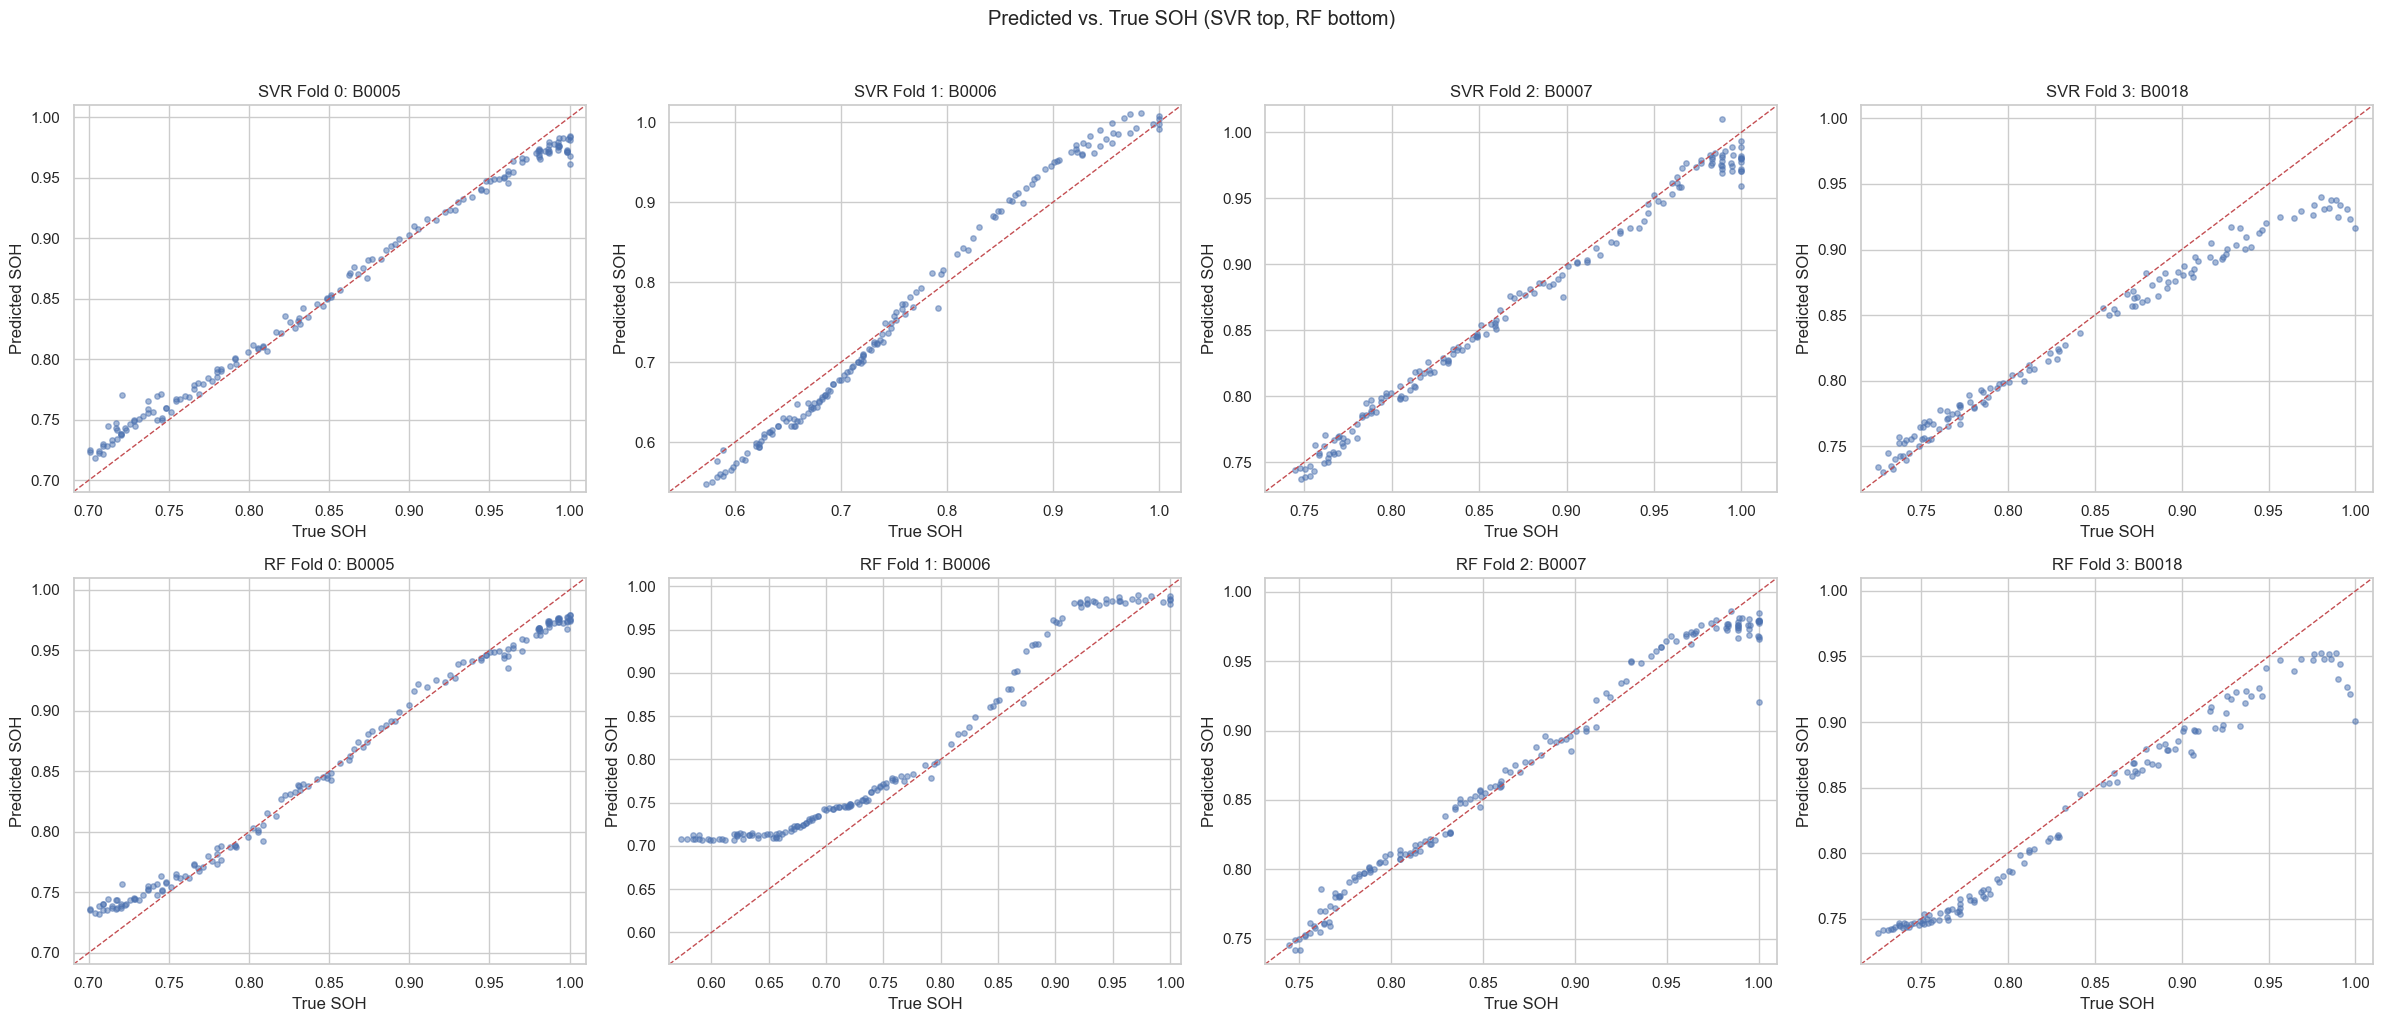

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

model_trainers = [
    ("SVR", train_svr, "svr"),
    ("RF", train_rf, "rf"),
]

for row, (display_name, trainer, cfg_key) in enumerate(model_trainers):
    cfg = config["models"]["classical"][cfg_key]
    if cfg_key == "rf":
        param_space = {
            "n_estimators": tuple(cfg["param_space"]["n_estimators"]),
            "max_depth": cfg["param_space"]["max_depth"],
            "min_samples_leaf": tuple(cfg["param_space"]["min_samples_leaf"]),
            "max_features": cfg["param_space"]["max_features"],
        }
    else:
        param_space = {
            "C": tuple(cfg["param_space"]["C"]),
            "epsilon": tuple(cfg["param_space"]["epsilon"]),
            "gamma": cfg["param_space"]["gamma"],
        }

    for i, fold in enumerate(folds):
        ax = axes[row, i]
        X_train_s, X_test_s, _ = scale_features(fold["X_train"], fold["X_test"])
        model, _, _ = trainer(
            X_train_s, fold["y_train"], X_test_s, fold["y_test"],
            n_trials=10,
            param_space=param_space,
        )
        y_pred = model.predict(X_test_s)

        ax.scatter(fold["y_test"], y_pred, alpha=0.5, s=15)
        lims = [
            min(fold["y_test"].min(), y_pred.min()) - 0.01,
            max(fold["y_test"].max(), y_pred.max()) + 0.01,
        ]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel("True SOH")
        ax.set_ylabel("Predicted SOH")
        ax.set_title(f"{display_name} Fold {i}: {fold['test_cell']}")

fig.suptitle("Predicted vs. True SOH (SVR top, RF bottom)", y=1.02)
plt.tight_layout()
plt.show()


## Summary

**Key findings:**
- SVR is the best classical model with RMSE=0.015 and R²=0.973 across all folds
- RF (RMSE=0.025, R²=0.927) and GPR (RMSE=0.030, R²=0.885) follow SVR
- All models comfortably beat the naive baseline (RMSE=0.112, R²=-0.285)
- Cell-based LOOCV reveals generalization gaps across cells
- B0018 (partial life) is the hardest fold due to limited training data